In [5]:
import numpy as np
from reader import *
import matplotlib.pyplot as plt
import math
from scipy import interpolate

In [6]:
geo = Reader("drafttube_shapes/baseline1/geo/diffuser.geo", cascade=False)
geo.size()

8320

In [7]:
#Connector, middle, diffuser have same pattern
#first 130 are even and odd
#rest are 65 points long

(65, 126, 2)


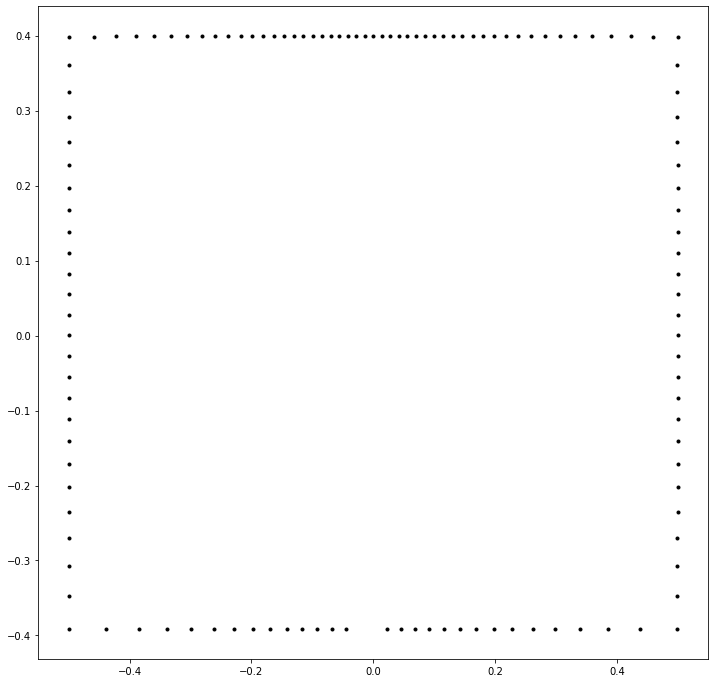

In [8]:
k = 130
layers = []

for n in range(65):
    layers.append([])
    for i in range(k, 8320, 65):
        layers[n].append(np.array(geo.collate_yz(i)))
    k += 1

layers = np.asarray(layers)
print(np.shape(layers))
plt.figure(figsize=(12,12))

x_layer = [layers[26][i][0] for i in range(len(layers[26]))]
y_layer = [layers[26][i][1] for i in range(len(layers[26]))]
y_layer_offset = [i + 0.475 for i in y_layer]
plt.plot(x_layer, y_layer_offset, 'k.')

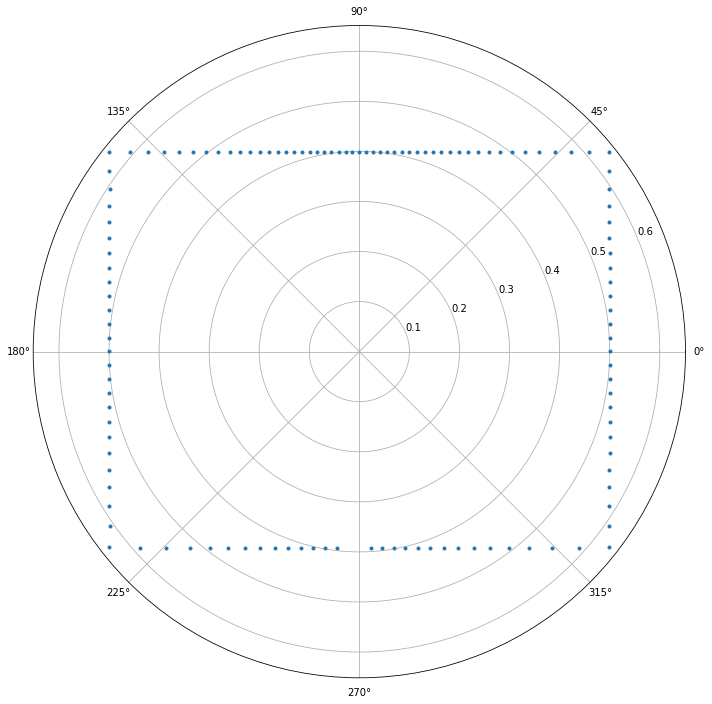

In [14]:
def cart2pol(x, y):
    """Convert a set of cartesian coordinates x, y to polar coordinates r, theta (default to radians)"""
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta

r_theta = np.array([cart2pol(x_layer[i], y_layer_offset[i]) for i in range(len(x_layer))])
#sorted_r_theta = sorted(r_theta, key = lambda x: x[1])

#r_plot = [r_theta[i][0] for i in range(len(r_theta))]
#theta_plot = [r_theta[i][1] for i in range(len(r_theta))]
plt.figure(figsize=(12,12))
#plt.polar(theta_plot, r_plot, '.')
#print(r_plot)
#print(theta_plot)
#print(max(theta_plot))
#print(min(theta_plot))
#print(r_theta)

sort = np.argsort(r_theta[:,1])
r_theta_sorted = r_theta[sort,:] # sorted pairs
#print(r_theta_sorted)

r_plot = [r_theta_sorted[i][0] for i in range(len(r_theta_sorted))]
theta_plot = [r_theta_sorted[i][1] for i in range(len(r_theta_sorted))]
#print(r_plot)
plt.polar(theta_plot, r_plot, '.')

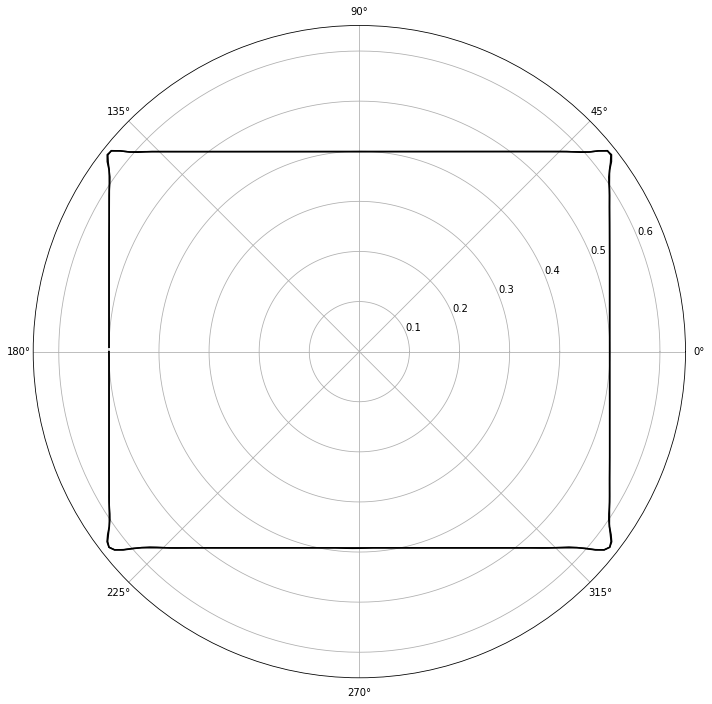

In [18]:
t = [i for i in range(-180, 180)]
t_rad = [np.deg2rad(t[i]) for i in range(len(t))]

plt.figure(figsize=(12,12))
#plt.polar(theta_plot, r_plot, '.')


#print(theta_plot)

f_pchip = interpolate.PchipInterpolator(theta_plot, r_plot)
f_cubic = interpolate.CubicSpline(theta_plot, r_plot)
#t = np.linspace(-math.pi, math.pi, 360)
plt.polar(t_rad, f_pchip(t_rad), 'k-')
plt.polar(t_rad, f_cubic(t_rad), 'k-')

In [5]:
x = np.array([r_theta[i][0] for i in range(len(r_theta))]) #np.array([points[i][0] for i in range(len(points))])
y = np.array([r_theta[i][1] for i in range(len(r_theta))]) #np.array([points[i][1] for i in range(len(points))])

#x = #np.array([layers[26][i][0] for i in range(len(layers[26]))])
#y = #np.array([layers[26][i][1] for i in range(len(layers[26]))])
# append the starting x,y coordinates
x = np.r_[x, x[0]]
y = np.r_[y, y[0]]
# fit splines to x=f(u) and y=g(u), treating both as periodic. also note that s=0
# is needed in order to force the spline fit to pass through all the input points.
tck, u = interpolate.splprep([x, y], s=0, per=True)
# evaluate the spline fits for 10000 evenly spaced distance values
xi, yi = interpolate.splev(np.linspace(0, 2*math.pi, 10000), tck) # 10000 points makes this accurate enough to be able to narrow down

#plt.figure(figsize=(12,12))
#plt.plot(yi, xi, '.')

In [146]:
def cart2pol(x, y):
    """Convert a set of cartesian coordinates x, y to polar coordinates r, theta (default to radians)"""
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta

def closest(lst, K):
    """Return the nearest value to integer K in a list of floating point values lst"""
    ind = min(range(len(lst)), key = lambda i: abs(lst[i] - K))
    print(ind)
    return lst[ind]
    #return [lst[ind - 1], lst[ind]]
    
def closest_2(lst, K):
    return min(lst, key = lambda i : abs)

def interpolate_polar(x, y):
    """Take the our i = 10000 interpolated points in Cartesian (x, y) space and return each 
    (r, theta) vector from [1, 360] degrees (360 = 0). Note that these vectors are not ordered.
    FIX: The indexes are messed up - [90] is 270deg, [180] is 360deg, [270] is 90deg, [0] is 180deg
    """
    pol = np.asarray([cart2pol(y[i], x[i]) for i in range(len(x))])# Convert to an (r, theta) numpy array, default in radians
    
    degs = []
    for i in range(len(pol)):
        deg = np.rad2deg(pol[i][1])
        degs.append(deg)
    print(degs[3500:4000])
    
    plt.figure(figsize=(12,12))
    r_plot = [pol[i][0] for i in range(len(pol))]
    theta_plot = [pol[i][1] for i in range(len(pol))]
    plt.polar(theta_plot, r_plot, '.')
    
    #pol_f = np.ndarray.flatten(pol) # Flatten to be able to manipulate and still be able to re-pair later on
    #for i in range(1, len(pol_f), 2): # Convert radians to degrees
        #deg = np.rad2deg(pol_f[i])
        #pol_f[i] = deg
    
    #print(pol_f[:100])
    
    degs_narrow = [] # List to append re-pair
    for i in range(-100, 100): # Find the closest discreet deg value for 360deg out of 10,000 points
        deg_close = closest(degs, i)
        #print(deg_close)
        degs_narrow.append(deg_close)
    #print(degs_narrow)
        
    #plt.figure(figsize=(12,12))
    #r_plot = [degs[i][0] for i in range(len(degs))]
    #theta_plot = [degs[i][1] for i in range(len(degs))]
    #plt.polar(theta_plot, r_plot, '.')
    #for i in range(len(degs)):
        #r = int(round(degs[i][1])) # Convert degree values to integers
        #degs[i][1] = r
        #if degs[i][1] <= 0: # Convert -180:180 to 0:360
            #degs[i][1] += 360
    #print(np.shape(degs_narrow))
    #return degs_narrow

[-98.45762944057815, -98.45513725390954, -98.4531823797424, -98.45175716655925, -98.45085396700703, -98.45046513681906, -98.45058303374833, -98.45120001651247, -98.4523084437502, -98.45390067298935, -98.45596905962647, -98.45850595591807, -98.46150370998375, -98.46495466482071, -98.46885115733046, -98.47318551735707, -98.47795006673752, -98.48313711836387, -98.48873897525765, -98.4947479296561, -98.50115626211085, -98.5079562405987, -98.51514011964466, -98.52270013945763, -98.53062852507834, -98.53891748554005, -98.54755921304177, -98.55654588213436, -98.56586964891957, -98.57552265026182, -98.5854970030133, -98.59578480325217, -98.60637812553404, -98.61726902215689, -98.62844952243958, -98.639911632014, -98.65164733213093, -98.66364857897997, -98.67590730302345, -98.68841540834445, -98.7011647720094, -98.71414724344483, -98.72735464382896, -98.74077876549802, -98.75441137136754, -98.76824419436845, -98.78226893689884, -98.79647727029072, -98.81086083429263, -98.82541123656773, -98.840

3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
3505
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6241
6186


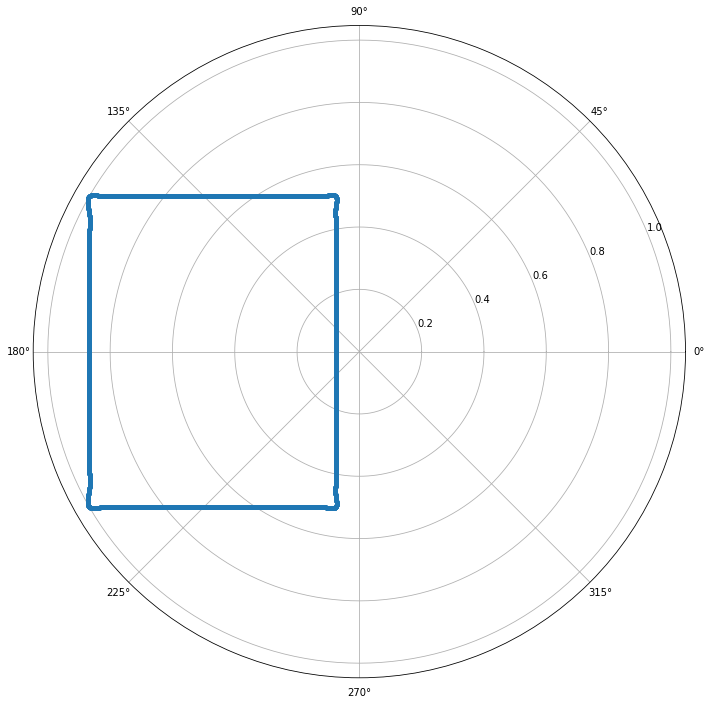

In [147]:
n = interpolate_polar(xi, yi)
#print(np.shape(n))

In [90]:
#plt.figure(figsize=(12,12))

r_plot = [n[i][0] for i in range(len(n))]
theta_plot = [np.deg2rad(n[i][1]) for i in range(len(n))]

print(np.rad2deg(theta_plot[90]))
print(np.rad2deg(theta_plot[180]))
print(np.rad2deg(theta_plot[270]))
print(np.rad2deg(theta_plot[0]))

plt.polar(theta_plot[90], r_plot[90], 'o')
plt.polar(theta_plot[180], r_plot[180], 'o')
plt.polar(theta_plot[270], r_plot[270], 'o')
plt.polar(theta_plot[0], r_plot[0], 'o')
plt.polar(theta_plot, r_plot, '.')

TypeError: object of type 'NoneType' has no len()